## Simulation of semidefinite program (SDP) linear program (LP)

The code below simulates the following SDP and LP:
\begin{align}
    \min_{X\in \mathbb{R}^{n\times n}} & \quad 0 \\
    \text{s.t.} & \quad AXA^\top=dd^\top \,, \\
    & \quad X_{ii} = 1 \quad \text{ for } i=1, \ldots, n \,, \\
    &\quad X\succeq 0\,,
\end{align}
where $A\in \mathbb{R}^{n\times m}$ is a Gaussian random matrix and $d = Ax \in \mathbb{R}^n$, where $x\in \mathbb{R}^m$ is sampled uniformly from $\left\{-1, 1\right\}^n$. Then we check, where the top eigenvector of $X$ coincides with the ground truth vector $x$ (up to sign). Then on the same instance the LP
\begin{align}
  \min_{\tilde x \in \mathbb{R}^m} & \quad \|\tilde x\|_\infty\\
  \text{s.t.} & \quad A \tilde x = d
\end{align}
and we check whether the solution $\tilde x$ coincides with the ground truth $x$. The results are saved in a csv, the user can pass an array of $n$ and an array of ratios $r\in [0,1]$ ($m := rn$ rounded to integer)

In [20]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
from collections import defaultdict
import os
import csv


def solve_lp(A, d):
  n = A.shape[1]
  x = cp.Variable(n)

  constraints = [
    A @ x == d,
    cp.norm_inf(x) <= 1
  ]

  # Feasibility = minimize a trivial objective
  prob = cp.Problem(cp.Minimize(cp.norm_inf(x)), constraints)

  # Solve (CVXOPT, OSQP, SCS, CBC, etc. can be used; lets use the default)
  prob.solve(solver=cp.SCS)

  if prob.status == "optimal" or prob.status == "optimal_inaccurate":
    return x.value
  else:
    return None

def top_eigenvector(X):
    w, v = np.linalg.eigh(X)
    return v[:, -1]

def solve_sdp(A,d):
  m = A.shape[0]
  n = A.shape[1]
  d = d.reshape(-1, 1)
  X = cp.Variable((n,n), PSD=True)
  constraints = [
    A @ X @ A.T == d @ d.T
  ]
  constraints.append(cp.diag(X) == np.ones(n))
  objective = cp.Minimize(0)
  prob = cp.Problem(objective, constraints)
  prob.solve(solver=cp.SCS)

  if prob.status == "optimal" or prob.status == "optimal_inaccurate":
    return X.value
  else:
    print(f"SDP solver status: {prob.status}")
    return None

def run_trial(args):
    A, d, x_true, n, ratio, trial_num = args
    n = A.shape[1]

    # Solve LP
    x_lp = solve_lp(A, d)
    lp_success = x_lp is not None and np.allclose(np.sign(x_lp), x_true)
    lp_correct_signs = 0 # Initialize correct signs count for LP
    if x_lp is not None:
        # Calculate correct signs for the LP solution
        lp_correct_signs = np.sum(np.sign(x_lp) == x_true)


    # Solve SDP
    X_sdp = solve_sdp(A, d)
    sdp_success = False
    sdp_rank = None
    sdp_correct_signs = 0 # Initialize correct signs count for SDP

    if X_sdp is not None:
        w_sdp, v_sdp_all = np.linalg.eigh(X_sdp)
        # Check all eigenvectors for a match (considering sign flip)
        for i in range(v_sdp_all.shape[1]):
            current_eigenvector = v_sdp_all[:, i]
            if np.allclose(np.sign(current_eigenvector), x_true) or np.allclose(np.sign(current_eigenvector), -x_true):
                sdp_success = True
                break # Found a matching eigenvector

        sdp_rank = np.linalg.matrix_rank(X_sdp, tol=1e-2)

        # Calculate correct signs for the top eigenvector
        top_v_sdp = top_eigenvector(X_sdp)
        # account for sign flip
        sign_match_count_pos = np.sum(np.sign(top_v_sdp) == x_true)
        sign_match_count_neg = np.sum(np.sign(top_v_sdp) == -x_true)
        sdp_correct_signs = max(sign_match_count_pos, sign_match_count_neg)


    # Return all relevant information
    return n, ratio, trial_num, lp_success, lp_correct_signs, sdp_success, sdp_rank, sdp_correct_signs


def save_results(filename, results):
    """Appends results to a CSV file."""
    n, ratio, trial_num, lp_success, lp_correct_signs, sdp_success, sdp_rank, sdp_correct_signs = results

    # Prepare the data row for the CSV
    row_data = [
        n,
        ratio,
        trial_num,
        lp_success,
        lp_correct_signs, # Add correct signs count for LP
        sdp_success,
        sdp_rank,
        sdp_correct_signs, # Add correct signs count for SDP
    ]

    # Check if the file exists to write the header only once
    file_exists = os.path.isfile(filename)
    with open(filename, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow([
                'n',
                'ratio',
                'trial_num',
                'lp_success',
                'lp_correct_signs', # Add header for correct signs for LP
                'sdp_success',
                'sdp_rank',
                'sdp_correct_signs', # Add header for correct signs for SDP
                ])
        writer.writerow(row_data)


def experiment(ns, num_trials, ratios, output_filename="experiment_results.csv"):
    """
    Runs the experiment and saves results incrementally.
    """
    print("Starting experiment...")

    # If the output file exists, inform the user but proceed (as state is not tracked)
    if os.path.exists(output_filename):
        print(f"Warning: Results file '{output_filename}' already exists. Results will be appended.")

    total_n_values = len(ns)
    total_ratios = len(ratios)

    for n_index in range(total_n_values):
        n = ns[n_index]
        print(f"\nRunning experiment for n={n}")

        for ratio_index in range(total_ratios):
            ratio = ratios[ratio_index]
            print(f"\nRatio: {ratio}")
            m = int(ratio * n)

            # Run trials sequentially
            for i in range(num_trials):
                print(f"Trial: {i}")
                A = np.random.randn(m, n)
                x_true = np.random.choice([-1, 1], size=n)
                d = A @ x_true

                # Run the trial and get detailed results
                results = run_trial((A, d, x_true, n, ratio, i))

                # Save the results
                save_results(output_filename, results)

    print("\nExperiment finished.")


# EXAMPLE:
ns = [20,30,40]
num_trials = 5
ratios = [0.2,0.3,0.4,0.5,0.6]

# SPECIFFY NAME OF OUTPUT FILE
output_csv = "experiment_results.csv"

experiment(ns, num_trials, ratios, output_filename=output_csv)

Starting experiment...

Running experiment for n=20

Ratio: 0.2
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.3
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.4
Trial: 0
Trial: 1
Trial: 2


/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Trial: 3
Trial: 4

Ratio: 0.5
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.6
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Running experiment for n=30

Ratio: 0.2
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.3
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.4
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.5
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.6
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Running experiment for n=40

Ratio: 0.2
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.3
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.4
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.5
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Ratio: 0.6
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4

Experiment finished.


# Analyzing and merging results
We provide methods to analyze and merge results from different trials, since SDP trials require large runtime.

In [21]:
import pandas as pd
import os

def merge_and_analyze_results(folder_path):
    """
    Merges csv files in specified folder and analyzes the number of trials
    per (n, ratio) pair.

    Args:
        folder_path (str): The path to the folder containing the CSV files.

    Returns:
        pandas.DataFrame: A DataFrame containing the number of trials for each
                          (n, ratio) pair.
    """
    all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

    if not all_files:
        print(f"No CSV files found in the folder: {folder_path}")
        return None

    # concatenate csv files
    df_list = [pd.read_csv(f) for f in all_files]
    merged_df = pd.concat(df_list, ignore_index=True)

    # Analyze the number of trials per (n, ratio) pair
    trial_counts = merged_df.groupby(['n', 'ratio'])['trial_num'].count().reset_index()
    trial_counts.rename(columns={'trial_num': 'num_trials'}, inplace=True)

    return merged_df, trial_counts # Return both the merged DataFrame and the trial counts

# EXAMPLE:
# For simple run CREATE folder called 'Results' and drop csv generated above into it
folder_path = 'Results' # specify folder with results
merged_df, analysis_results = merge_and_analyze_results(folder_path)

if merged_df is not None:
    # Save the merged df to new csv
    output_merged_csv = 'merged_results.csv'
    merged_df.to_csv(output_merged_csv, index=False)
    print(f"Merged results saved to {output_merged_csv}")

if analysis_results is not None:
    print("Number of trials per (n, ratio) pair:")
    display(analysis_results)

Merged results saved to merged_results.csv
Number of trials per (n, ratio) pair:


,n,ratio,num_trials
0,20,0.2,5
1,20,0.3,5
2,20,0.4,5
3,20,0.5,5
4,20,0.6,5
5,30,0.2,5
6,30,0.3,5
7,30,0.4,5
8,30,0.5,5
9,30,0.6,5


In [22]:
# SPECIFY the path to your merged results CSV file
file_path = 'merged_results.csv'

# Read the CSV file into a pandas DataFrame
try:
    merged_df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}' into a DataFrame.")
    # Display the first few rows of the DataFrame to verify
    print("\nFirst 5 rows of the DataFrame:")
    display(merged_df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure the file is in the correct directory or provide the full path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

# Now you can use the 'merged_df' DataFrame for further analysis or processing
# For example, you could then pass it to the balance_trials_per_n function:
# balanced_df = balance_trials_per_n(merged_df)
# display(balanced_df)

Successfully loaded 'merged_results.csv' into a DataFrame.

First 5 rows of the DataFrame:


,n,ratio,trial_num,lp_success,lp_correct_signs,sdp_success,sdp_rank,sdp_correct_signs
0,20,0.2,0,True,20,True,1,20
1,20,0.2,1,False,13,False,17,12
2,20,0.2,2,False,13,False,17,13
3,20,0.2,3,False,13,False,17,13
4,20,0.2,4,False,14,False,17,14


Generating recovery percentage plots from CSV...
Successfully loaded 'merged_results.csv' into a DataFrame for plotting.


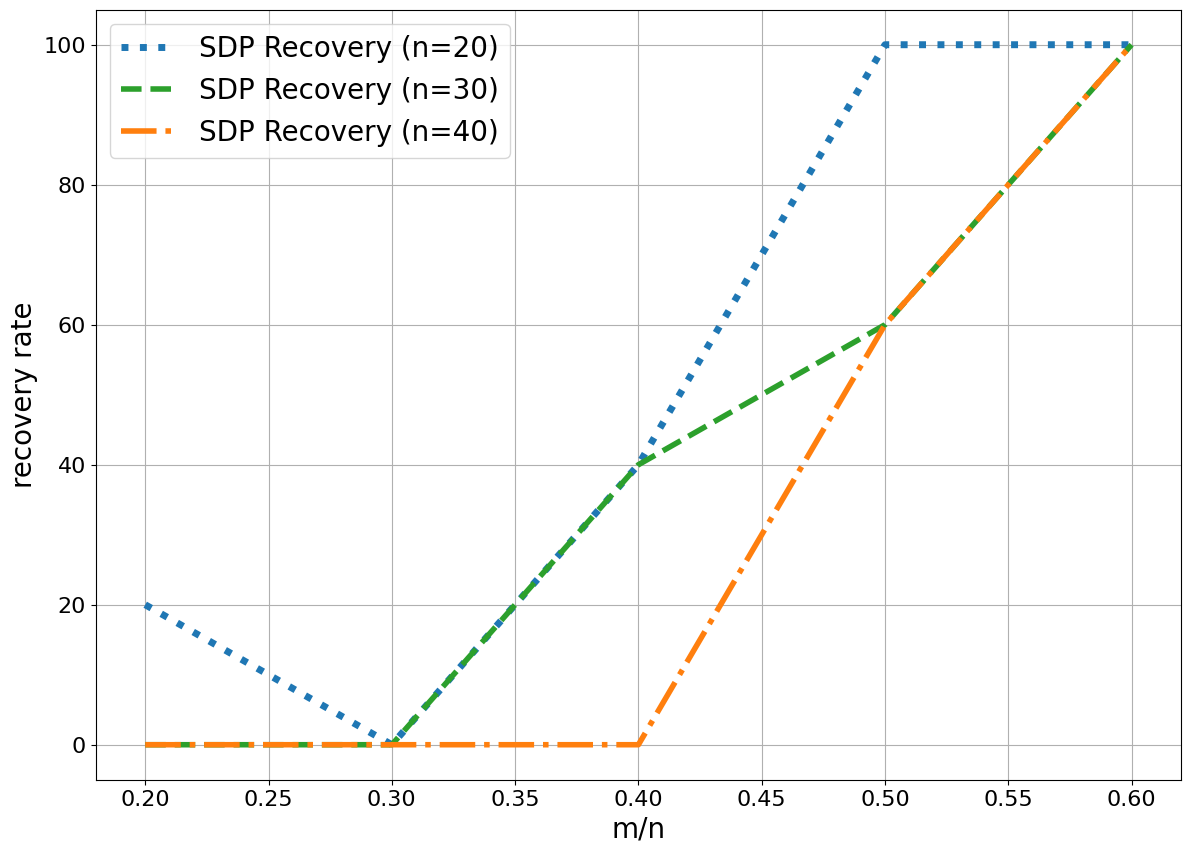


Analyzing SDP rank distribution from CSV for cases where SDP succeeded and LP failed...
Successfully loaded 'merged_results.csv' into a DataFrame for rank analysis.

SDP Rank Distribution (SDP Success & LP Fail):

For n = 20:


,count
sdp_rank,
1,1
2,1
3,2



For n = 30:


,count
sdp_rank,
1,1


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import numpy as np # Import numpy for linspace
from matplotlib import rcParams # For changing font size


def plot_recovery_percentage(csv_file_path):
    """
    Loads experiment results from a CSV, calculates recovery percentages for LP and SDP,
    and generates plots showing the recovery percentage vs. ratio for each value of n,
    with larger fonts, legend, no title, and different line styles per n.

    Args:
        csv_file_path (str): The path to the experiment results CSV file (e.g., balanced_results.csv).
    """
    # Check if the file exists
    if not os.path.exists(csv_file_path):
        print(f"Error: The file '{csv_file_path}' was not found.")
        return

    # Load the data from the CSV file
    try:
        df = pd.read_csv(csv_file_path)
        print(f"Successfully loaded '{csv_file_path}' into a DataFrame for plotting.")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        return


    n_values = sorted(df['n'].unique())

    # Create a single figure for all n values
    plt.figure(figsize=(14, 10))

    # Set font sizes (matching the LP plot adjustments)
    plt.rcParams.update({'font.size': 26}) # Base font size

    # Define line styles and colors for each n value
    # Get a color map and generate a list of colors for each n
    # define exactly the three colors you want
    cycle = rcParams['axes.prop_cycle'].by_key()['color']

    # pick blue, green, orange - add more if needed for more n values
    colors = [cycle[0], cycle[2], cycle[1]]
    line_styles = [':', '--', '-.'] # Add more if needed

    # Create maps for colors and line styles
    color_map = dict(zip(n_values, colors[:len(n_values)]))
    style_map = dict(zip(n_values, line_styles[:len(n_values)]))

    # Define linewidths, making the dotted line thicker
    linewidths = {
        ':': 5,
        '--': 4,
        '-.': 4,
        '-': 2 # Default
    }


    for n_value in n_values: # Sort n values for consistent plot order
        df_n = df[df['n'] == n_value].copy()

        # Group by ratio and calculate recovery percentages
        recovery_stats = df_n.groupby('ratio').agg(
            lp_success_percentage=('lp_success', lambda x: (x.sum() / len(x)) * 100),
            sdp_success_percentage=('sdp_success', lambda x: (x.sum() / len(x)) * 100)
        ).reset_index()

        # Get the line style and color for the current n
        current_linestyle = style_map.get(n_value, '-')
        current_color = color_map.get(n_value, None) # Let matplotlib choose if color not in map
        current_linewidth = linewidths.get(current_linestyle, 2)


        # Plot only SDP Recovery for the current n on the single figure
        plt.plot(recovery_stats['ratio'], recovery_stats['sdp_success_percentage'],
                 linestyle=current_linestyle,
                 linewidth=current_linewidth,
                 color=current_color,
                 label=f'SDP Recovery (n={n_value})')

    plt.xlabel('m/n', fontsize=20) # Specific font size for label
    plt.ylabel('recovery rate', fontsize=20) # Specific font size for label
    plt.grid(True)
    plt.legend(loc='best', fontsize=20, title_fontsize=22) # Increased legend font size and title size
    plt.xticks(fontsize=16) # Specific font size for ticks
    plt.yticks(fontsize=16) # Specific font size for ticks


    plt.show()


def analyze_sdp_rank_distribution(csv_file_path):
    """
    Loads experiment results from a CSV and analyzes the distribution of SDP ranks
    for cases where SDP succeeded but LP failed, for each value of n.

    Args:
        csv_file_path (str): The path to the experiment results CSV file (e.g., balanced_results.csv).

    Returns:
        dict: A dictionary where keys are 'n' values and values are pandas
              Series containing the distribution of SDP ranks for those cases.
    """
    # Check if the file exists
    if not os.path.exists(csv_file_path):
        print(f"Error: The file '{csv_file_path}' was not found.")
        return None # Return None if file not found

    # Load the data from the CSV file
    try:
        df = pd.read_csv(csv_file_path)
        print(f"Successfully loaded '{csv_file_path}' into a DataFrame for rank analysis.")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        return None # Return None if error occurs during loading

    # Filter for cases where SDP succeeded and LP failed
    sdp_success_lp_fail_df = df[(df['sdp_success'] == True) & (df['lp_success'] == False)].copy()

    rank_distributions = {}

    n_values = sdp_success_lp_fail_df['n'].unique()

    for n_value in sorted(n_values): # Sort n values for consistent output order
        df_n = sdp_success_lp_fail_df[sdp_success_lp_fail_df['n'] == n_value].copy()

        # Get the value counts of SDP ranks for this n
        rank_counts = df_n['sdp_rank'].value_counts().sort_index()

        if not rank_counts.empty:
             rank_distributions[n_value] = rank_counts
        else:
             print(f"No cases found where SDP succeeded and LP failed for n = {n_value}")


    return rank_distributions

# --- Example Usage (using CSV file path) ---

# Specify the path to your balanced results CSV file
balanced_csv_path = 'merged_results.csv' # Make sure this matches the filename where you saved balanced_df

# 1. Generate and display the recovery percentage plots using the CSV
print("Generating recovery percentage plots from CSV...")
plot_recovery_percentage(balanced_csv_path)


# 2. Analyze and display the SDP rank distribution using the CSV
print("\nAnalyzing SDP rank distribution from CSV for cases where SDP succeeded and LP failed...")
rank_distributions = analyze_sdp_rank_distribution(balanced_csv_path)

if rank_distributions:
    print("\nSDP Rank Distribution (SDP Success & LP Fail):")
    for n_value, rank_counts in rank_distributions.items():
        print(f"\nFor n = {n_value}:")
        display(rank_counts) # Display the Series nicely in Colab
else:
    print("\nNo cases found where SDP succeeded and LP failed across all 'n' values or file not found/loaded.")

## Linear program (only) experiments
Since the linear programs run faster, we provide methods to only run and analyize the linear program

In [24]:
def run_lp_experiment(ns, num_trials, ratios, output_filename="lp_experiment_results.csv"):
    """
    Runs the LP part of the experiment and saves results incrementally.

    Args:
        ns (list): A list of integer values for n.
        num_trials (int): The number of trials to run for each (n, ratio) pair.
        ratios (list): A list of float values for the ratio m/n.
        output_filename (str): The name of the CSV file to save results to.
    """
    print("Starting LP experiment...")

    # If the output file exists, inform the user but proceed (as state is not tracked)
    if os.path.exists(output_filename):
        print(f"Warning: Results file '{output_filename}' already exists. Results will be appended.")

    total_n_values = len(ns)
    total_ratios = len(ratios)

    # Prepare the header for the CSV file
    header = [
        'n',
        'ratio',
        'trial_num',
        'lp_success',
        'lp_correct_signs',
    ]

    # Check if the file exists to write the header only once
    file_exists = os.path.isfile(output_filename)
    with open(output_filename, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(header)

    for n_index in range(total_n_values):
        n = ns[n_index]
        print(f"\nRunning LP experiment for n={n}")

        for ratio_index in range(total_ratios):
            ratio = ratios[ratio_index]
            print(f"Ratio: {ratio}")
            m = int(ratio * n)

            # Run trials sequentially
            for i in range(num_trials):
                # print(f"Trial: {i}") # Uncomment for more detailed progress
                A = np.random.randn(m, n)
                x_true = np.random.choice([-1, 1], size=n)
                d = A @ x_true

                # Solve LP
                x_lp = solve_lp(A, d)
                lp_success = x_lp is not None and np.allclose(np.sign(x_lp), x_true)
                lp_correct_signs = 0
                if x_lp is not None:
                    lp_correct_signs = np.sum(np.sign(x_lp) == x_true)

                # Prepare the data row for the CSV
                row_data = [
                    n,
                    ratio,
                    i, # trial_num
                    lp_success,
                    lp_correct_signs,
                ]

                # Save the results
                with open(output_filename, 'a', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(row_data)

    print("\nLP experiment finished.")

# # Example usage (uncomment to run):
lp_ns = [20, 50, 80]
lp_num_trials = 20
lp_ratios = np.linspace(0.2,0.8,30)
lp_output_csv = "lp_experiment_results.csv"
#
run_lp_experiment(lp_ns, lp_num_trials, lp_ratios, output_filename=lp_output_csv)

Starting LP experiment...

Running LP experiment for n=20
Ratio: 0.2
Ratio: 0.22068965517241382
Ratio: 0.2413793103448276
Ratio: 0.2620689655172414
Ratio: 0.2827586206896552
Ratio: 0.303448275862069
Ratio: 0.3241379310344828
Ratio: 0.3448275862068966
Ratio: 0.3655172413793104
Ratio: 0.3862068965517242
Ratio: 0.40689655172413797
Ratio: 0.4275862068965518
Ratio: 0.4482758620689656
Ratio: 0.46896551724137936
Ratio: 0.48965517241379314
Ratio: 0.510344827586207
Ratio: 0.5310344827586208
Ratio: 0.5517241379310345
Ratio: 0.5724137931034483
Ratio: 0.5931034482758621
Ratio: 0.613793103448276
Ratio: 0.6344827586206898
Ratio: 0.6551724137931035
Ratio: 0.6758620689655173
Ratio: 0.6965517241379311
Ratio: 0.7172413793103449
Ratio: 0.7379310344827588
Ratio: 0.7586206896551726
Ratio: 0.7793103448275862
Ratio: 0.8

Running LP experiment for n=50
Ratio: 0.2
Ratio: 0.22068965517241382
Ratio: 0.2413793103448276
Ratio: 0.2620689655172414
Ratio: 0.2827586206896552
Ratio: 0.303448275862069
Ratio: 0.324137931

**Reasoning**:
Load the data from the specified CSV file into a pandas DataFrame.



Successfully loaded 'lp_experiment_results.csv' into a DataFrame.


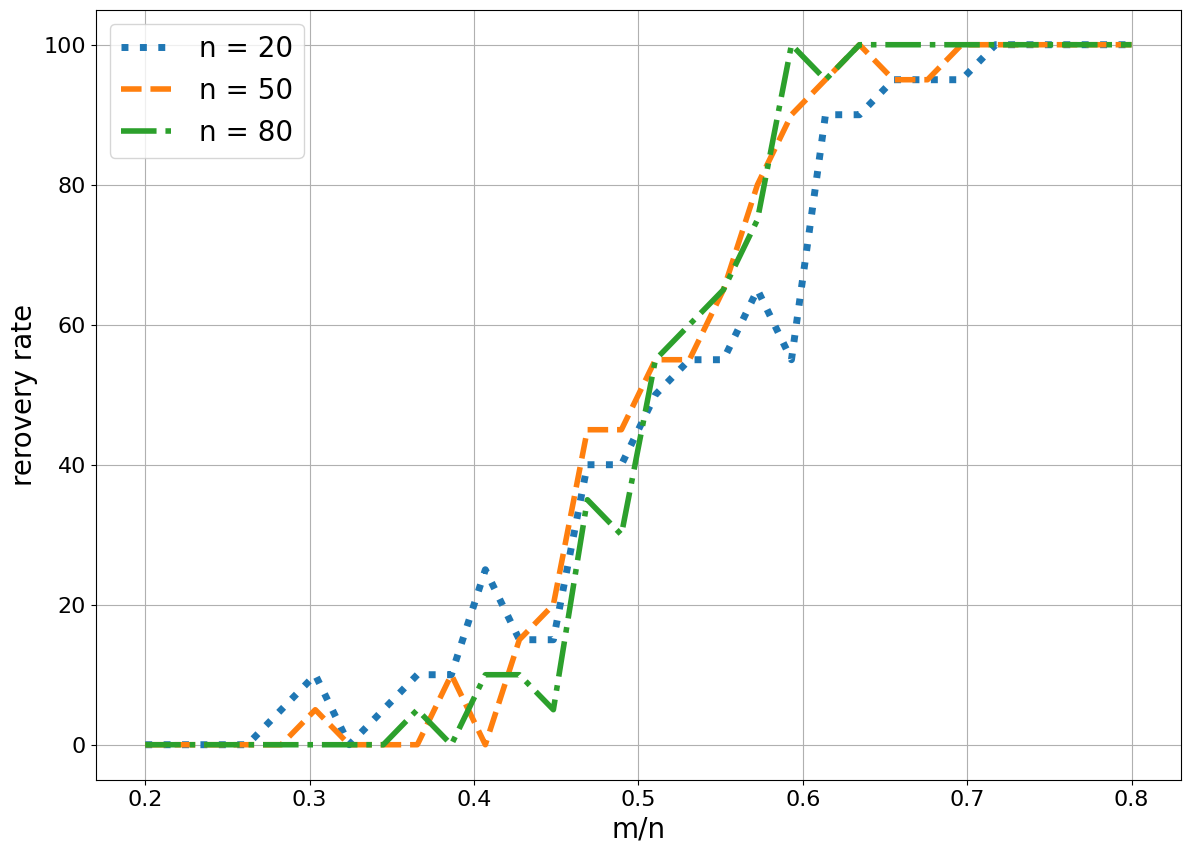

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_lp_recovery_from_csv(csv_file_path):
    """
    Loads LP experiment results from a CSV, calculates recovery percentages,
    and plots recovery percentage vs. ratio for each n on a single plot
    with larger fonts, legend, no title, and different line styles per n.

    Args:
        csv_file_path (str): The path to the LP experiment results CSV file.
    """
    # Check if the file exists
    if not os.path.exists(csv_file_path):
        print(f"Error: The file '{csv_file_path}' was not found.")
        return

    # Load the data from the CSV file
    try:
        lp_results_df = pd.read_csv(csv_file_path)
        print(f"Successfully loaded '{csv_file_path}' into a DataFrame.")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        return

    # Calculate the LP success percentage for each (n, ratio) pair
    lp_recovery_stats = lp_results_df.groupby(['n', 'ratio'])['lp_success'].mean().reset_index()

    # Convert the mean (which is the proportion of True values) to a percentage
    lp_recovery_stats['lp_success_percentage'] = lp_recovery_stats['lp_success'] * 100

    # Create the plot with increased figure size for better readability with larger fonts
    plt.figure(figsize=(14, 10))

    # Set font sizes
    plt.rcParams.update({'font.size': 26}) # Set a base font size for better readability

    # Define line styles for each n value
    n_values = sorted(lp_recovery_stats['n'].unique())
    line_styles = {
        n_values[0]: ':',  # Dotted for smallest n
        n_values[1]: '--', # Dashed for second smallest n
        n_values[2]: '-.'  # Dash-dot for largest n (or you can use a custom dash pattern)
    }

    # Define linewidths, making the dotted line thicker
    linewidths = {
        n_values[0]: 5,  # Thicker for dotted line
        n_values[1]: 4,
        n_values[2]: 4
    }


    # Plot recovery percentage for each unique n with different line styles
    for n_value in n_values:
        df_n = lp_recovery_stats[lp_recovery_stats['n'] == n_value]
        plt.plot(df_n['ratio'], df_n['lp_success_percentage'], linestyle=line_styles.get(n_value, '-'), linewidth=linewidths.get(n_value, 2), label=f'n = {n_value}') # Default to solid and linewidth 2 if n not in dicts

    plt.xlabel('m/n', fontsize=20)
    plt.ylabel('rerovery rate', fontsize=20)
    plt.grid(True)
    plt.legend(loc='best', fontsize=20, title_fontsize=22)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.show()

# # Example usage (uncomment to run):
lp_output_csv = "lp_experiment_results.csv" # Make sure this matches the filename used before
plot_lp_recovery_from_csv(lp_output_csv)